# LeetCode #206: Reverse Linked List

https://leetcode.com/problems/reverse-linked-list/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Recursive** | $O(n)$ | $O(n)$ call stack |
| **Optimal: Iterative** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Recursive
Recurse to the end of the list. The last node becomes the new head. On the way back, each node makes its next node point back to it: `curr.next.next = curr`, then clears its own `next`. Returns the new head (the original tail) all the way up. Uses $O(n)$ stack space.

### Optimal: Iterative ★
Use three pointers: `prev` (starts null), `curr` (starts at head), and `next` (temporary).
1. Save `curr.next` as `next`.
2. Reverse the link: `curr.next = prev`.
3. Advance: `prev = curr`, `curr = next`.
4. When `curr` is null, `prev` is the new head.

**Why this works:** Each node's pointer is flipped exactly once. We walk forward through the original list while building the reversed list behind us.

**Constraints:**
* `0 <= n <= 5000`
* `-5000 <= Node.val <= 5000`

## Solutions

### C#

In [ ]:
public class Solution {
    public ListNode ReverseList(ListNode head) {
        ListNode prev = null;
        ListNode curr = head;
        
        while (curr != null) {
            ListNode next = curr.next;
            curr.next = prev;
            prev = curr;
            curr = next;
        }
        
        return prev;
    }
}

### Python

In [ ]:
class Solution:
    def reverseList(self, head):
        prev = None
        curr = head
        
        while curr:
            nxt = curr.next
            curr.next = prev
            prev = curr
            curr = nxt
        
        return prev

### Go

In [ ]:
func reverseList(head *ListNode) *ListNode {
    var prev *ListNode
    curr := head
    
    for curr != nil {
        next := curr.Next
        curr.Next = prev
        prev = curr
        curr = next
    }
    
    return prev
}

### Rust

In [ ]:
impl Solution {
    pub fn reverse_list(head: Option<Box<ListNode>>) -> Option<Box<ListNode>> {
        let mut prev = None;
        let mut curr = head;
        
        while let Some(mut node) = curr {
            curr = node.next.take();
            node.next = prev;
            prev = Some(node);
        }
        
        prev
    }
}

## Example Scenarios

1. **Common Case:** `head = [1,2,3,4,5]` → `[5,4,3,2,1]`. Use three pointers (prev, curr, next). Each iteration: save `curr.next`, flip `curr.next = prev`, advance both. After 5 iterations, `prev` = 5 (new head). WHY tricky: Must save `curr.next` BEFORE overwriting it — otherwise we lose the rest of the list. The order (save, reverse, advance) is critical.

2. **Slightly Complex — Two Elements:** `head = [1,2]` → `[2,1]`. The minimal non-trivial case. Only one pointer flip needed: $2.\text{next} = 1$, $1.\text{next} = \text{null}$. Loop runs exactly twice (once per node). WHY tricky: Easy to confuse whether the loop body executes once or twice — it executes $n$ times, not $n-1$.

3. **Edge Case — Time Factor (5000 Nodes):** `head = [1,2,...,5000]` → `[5000,...,2,1]`. At the constraint maximum, iterative: 5000 iterations $\times$ 4 operations each = 20,000 ops. Recursive would need 5000 stack frames ($\approx 250$KB stack). WHY tricky: Both are $O(n)$ time, but recursion risks stack overflow at $n = 5000$ (Python default depth $\approx 1000$). Iterative is strictly safer.

4. **Edge Case — Space Factor (Empty and Single):** `head = []` → `[]` and `head = [42]` → `[42]`. Empty: `curr` starts null, loop never runs, return `prev` (null). Single: loop runs once, node's next set to null (already null). Both use $O(1)$ space. WHY tricky: The `while(curr != null)` guard handles both degenerate cases without special-case code.

5. **Almost-Impossible — Extreme Values:** `head = [-5000,-5000,0,5000,5000]` → `[5000,5000,0,-5000,-5000]`. Node values at constraint boundaries ($-5000$ to $5000$). The algorithm never reads `node.val` — it only manipulates next pointers. WHY tricky: Verifies the algorithm is purely structural. Interviewers may ask "Does your solution handle negative values?" — yes, trivially, because values are irrelevant to pointer reversal.

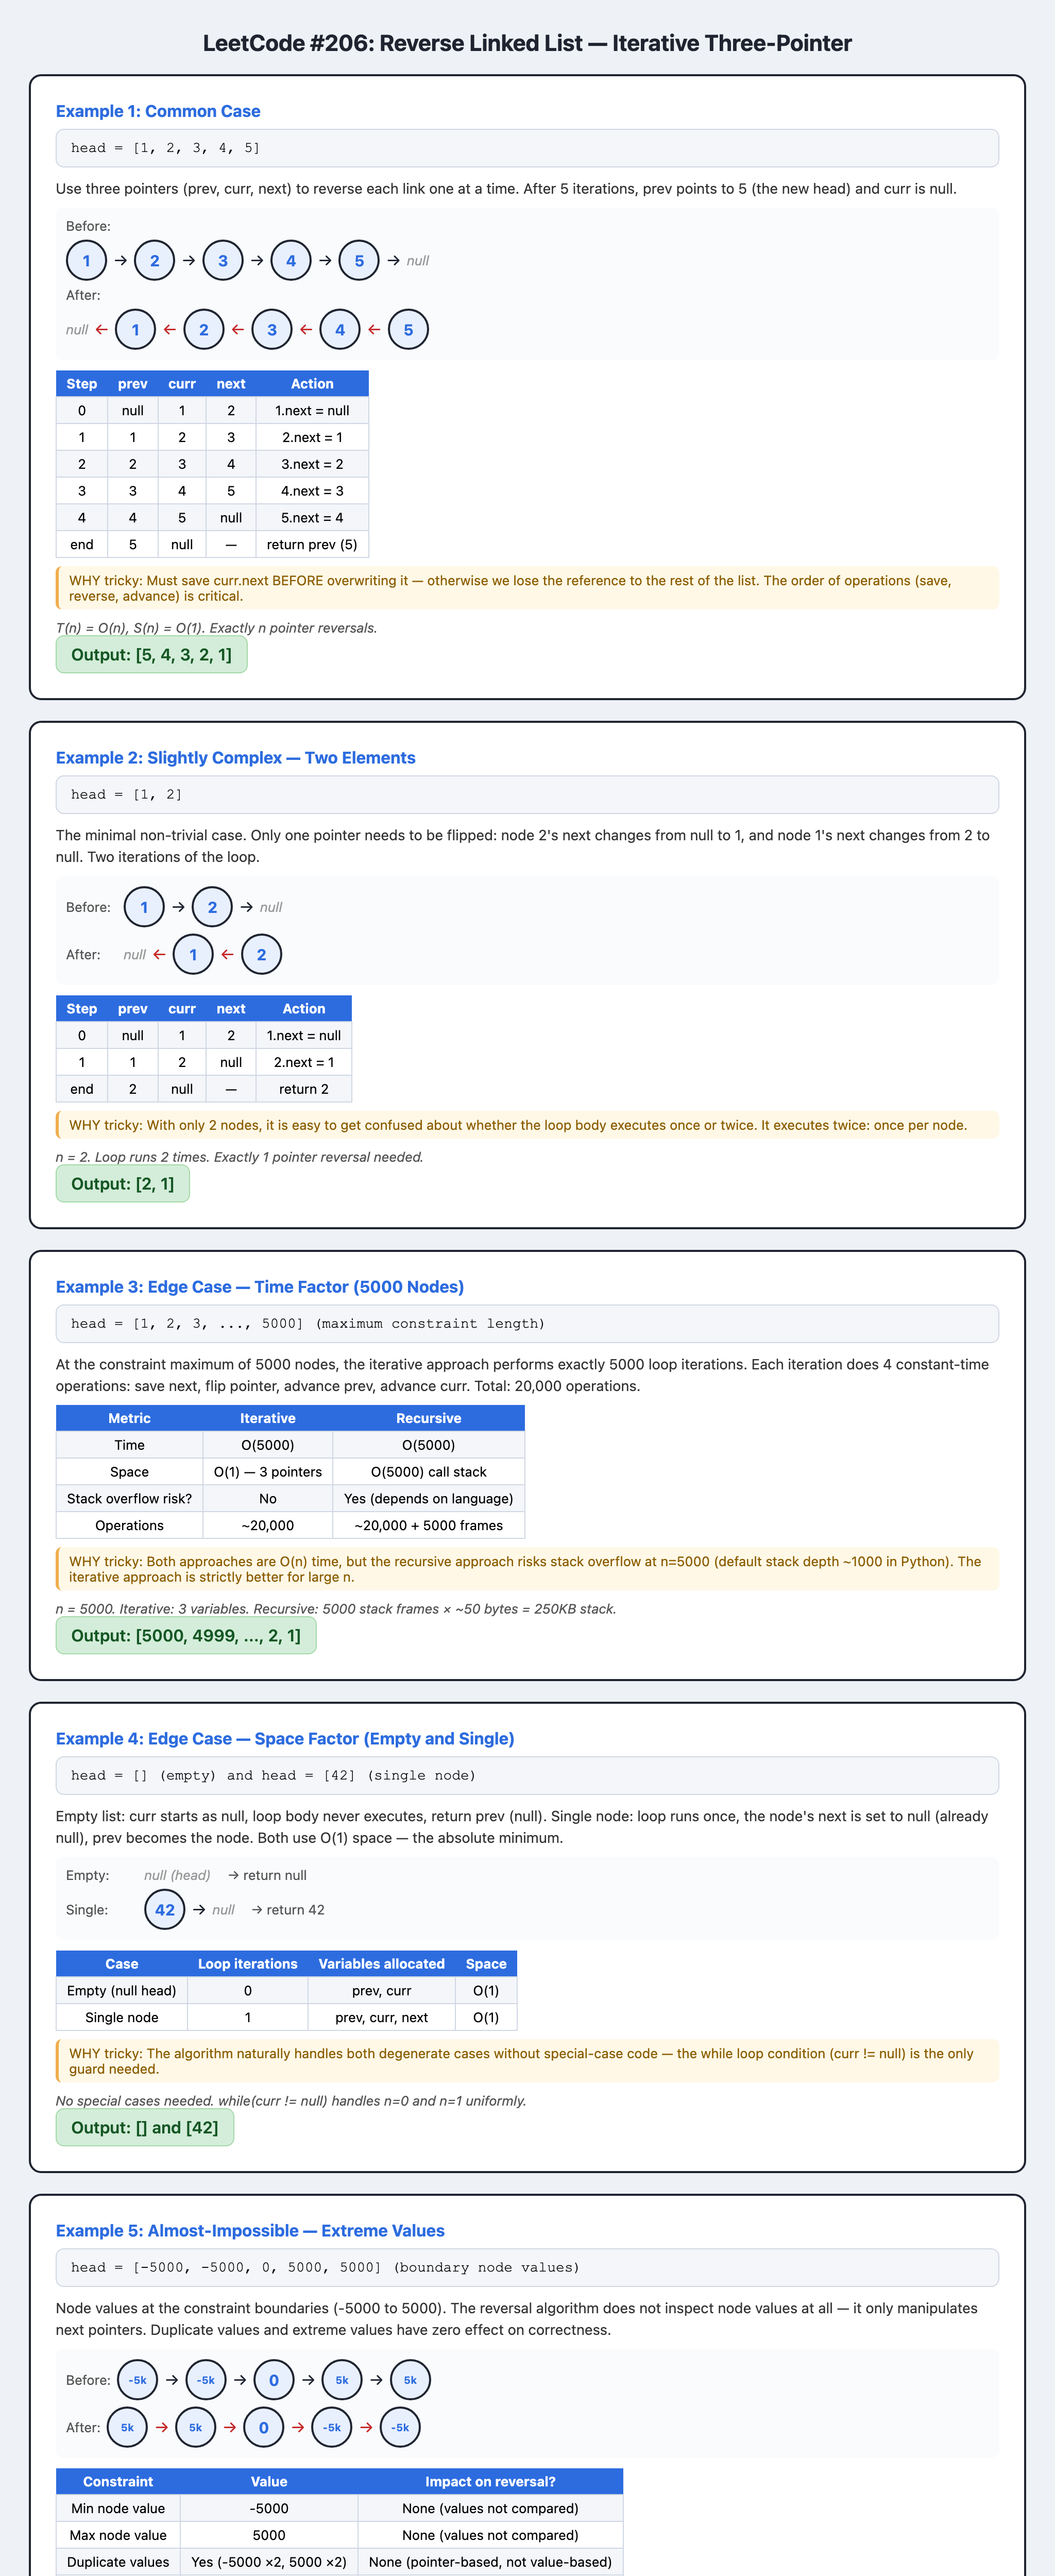